 Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CUDA
 Initializing GlassBox-ViT (ShapExplainer)...
Loading and resizing test image (Chelsea the cat)...
Generating SHAP explanation...

 SHAP TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%


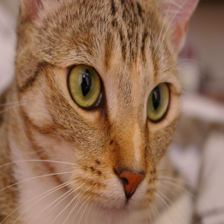

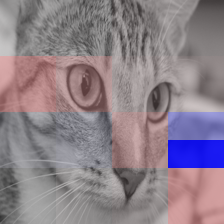

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

# Importing our library
from glassbox_vit.shap_explainer import ShapExplainer

# ---  MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)
model.eval()

# Extract classes and define standard ViT size (224x224)
class_names = list(model.config.id2label.values())
image_shape = (224, 224, 3)

# ---  BRIDGE FUNCTION ---
def hf_prediction_function(images_numpy):
    imgs_pil = [Image.fromarray((img).astype('uint8')) for img in images_numpy]
    inputs = processor(images=imgs_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (ShapExplainer)...")
shap_explainer = ShapExplainer(
    prediction_function=hf_prediction_function,
    class_names=class_names,
    image_shape=image_shape
)

# --- LOAD TEST IMAGE  ---
print("Loading and resizing test image (Chelsea the cat)...")
image_np = data.chelsea()
# Convert to PIL and force to 224x224 to fit perfectly with ViT
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- THE  TEST ---
print("Generating SHAP explanation...")
# WARNING: Setting max_evals=50 just so this test takes a few seconds.
# In your real code, use 300 or 500 for better quality.
result = shap_explainer.generate(
    pil_image=test_image,
    max_evals=50,
    batch_size=8
)

# ---  DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = class_names[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n SHAP TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")

# Display the image directly in the notebook cell output
display(test_image)
display(result['shap_image'])